<div style="font-size:1.4em; margin-bottom:2em">
    <div style="float:right; line-height:1.2em;">GET Lab<br />Paderborn University</div>
  <div>WS 2021/22</div>
</div>
<div style="clear:both"></div>
<div style="text-align:center; font-size:1.8em;">
  Digital Image Processing I<br />Exam - Programming Tasks
</div>

<hr>

### Introduction
Execute the following code for the required imports and to load the function to plot an image in the original size. The test images are in the folder *images*.

In [42]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

dpi = plt.rcParams['figure.dpi']

# plot image in original size
def plot_img_orig(img):
    fig = plt.figure(figsize = (img.shape[1]/dpi, img.shape[0]/dpi))
    fig.add_axes([0, 0, 1, 1])
    plt.axis('off')
    plt.imshow(img, cmap='gray', vmin=0, vmax=255) # cmap parameter is ignored for RGB(A) data
    plt.show()

In [43]:
# based on the log transformation from task sheet 4
def log_transformation(img):
    # create empty image
    rows, cols = img.shape # image size
    res = np.zeros(shape=[rows, cols], dtype=np.float64) # init with zeros

    for i in range(rows):
        for j in range(cols):
            c = 255 / np.log(1 + np.amax(img)) # normalize result to 255*[0,1]
            res[i, j] = c * np.log(1 + img[i, j]) # min of log = 0, max = np.log(1 + img[i, j])
            
    # return result
    return res

---

<div style="font-size:1.4em;"><span style="color:RoyalBlue; font-weight:bold;">Task 1.7</span> (5 P)</div>

The following image with $30 \times 300$ pixels shows a sequence of alternating medium gray and black squares (10 squares in total). Complete the given function so that it returns such an image. The number of squares and their side lengths should be parameters. Use your function to reproduce the image and plot the result.

<p style="text-align:center;">
  <img src="images/squares.png" width="300px" />
</p>

In [44]:
# number = number of squares, sidelength = side length of one square in px
def draw_squares(number, sidelength):

    # ...

SyntaxError: unexpected EOF while parsing (<ipython-input-44-759818907b20>, line 4)

<div style="font-size:1.4em;"><span style="color:RoyalBlue; font-weight:bold;">Task 2.2</span> (5 P)</div>

The input image *pollen.png* has been processed with an unknown gray-level transformation, the output image is *pollen-tf.png*.

<p style="text-align:center;">
<table>
<tr>
  <td style="text-align:center;">Input image</td>
  <td style="text-align:center;">Output image</td>
</tr>
<tr>
  <td><img src="images/pollen.png" width="300px" /></td>
  <td><img src="images/pollen-tf.png" width="300px" /></td>
</tr>
<tr>
  <td style="text-align:center; font-style:italic;">pollen.png</td>
  <td style="text-align:center; font-style:italic;">pollen-tf.png</td>
</tr>
</table>
</p>

Implement a function which returns the corresponding transformation function `tf` in numerical form and plot it.

In [45]:
# img_in = input image, img_out = result after transformation
def compute_tf(img_in, img_out):
    rows, cols = img_in.shape
    tf = np.zeros(256, dtype=np.uint8)

    for row in range(rows):
        for col in range(cols):
            tf[img_in[row, col]] = img_out[row, col]

    return tf.astype(np.uint8) # tf = transformation function

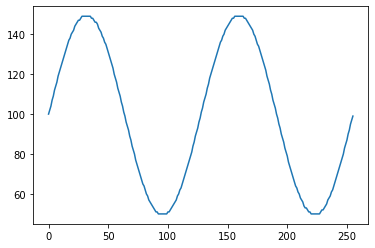

In [46]:
img_in = cv2.imread('images/pollen.png', 0)
img_out = cv2.imread('images/pollen-tf.png', 0)
x = np.arange(256)
plt.plot(x, compute_tf(img_in, img_out))
tf = compute_tf(img_in, img_out)

<div style="font-size:1.4em;"><span style="color:RoyalBlue; font-weight:bold;">Task 4.5</span> (5 P)</div>

<p style="text-align:center;">
  <img src="images/gauss.png" width="300px" />
</p>

a) Implement a function which returns a $n \times n$ Gaussian filter mask `g` with given standard deviation based on the 2D Gaussian from above. For this purpose, set $K = 1$.

b) Use this function and an appropriate pre-factor to reproduce the mask $w_3(x,y)$ from the previous subtask. Use `print` to print the mask.

c) Filter the image *pollen.png* with the mask $w_3(x,y)$ and an appropriate normalization factor. Plot the result.

In [47]:
# sigma = standard deviation, n = mask size (odd)
def gaussian(sigma, n):
    # create empty mask
    g = np.zeros(shape=[n, n], dtype=np.float64) 
    rows, cols = g.shape
    c = int(n/2)

    for row in range(rows):
        for col in range(cols):
            r2 = (row-c)**2 + (col-c)**2
            g[row, col] = np.exp(-r2/(2*sigma**2))
    return g

In [48]:
g = 24*gaussian(0.9, 3)
g = g.astype('int64')
print(g)

[[ 6 12  6]
 [12 24 12]
 [ 6 12  6]]


<div style="font-size:1.4em;"><span style="color:RoyalBlue; font-weight:bold;">Task 5.4</span> (5 P)</div>

The image *cells.png* with $300 \times 300$ pixels is interrupted by a regular pattern. Remove the pattern by processing the image in the frequency domain and plot the corrected image.

<p style="text-align:center;">
  <img src="images/cells.png" width="300px" /><br />
  <span style="font-style:italic;">cells.png</span>
</p>

Input image:


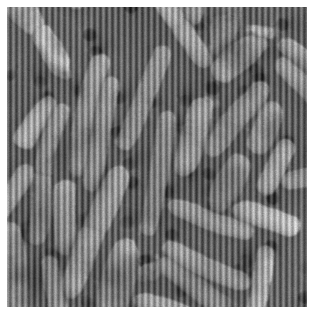

Spectrum:


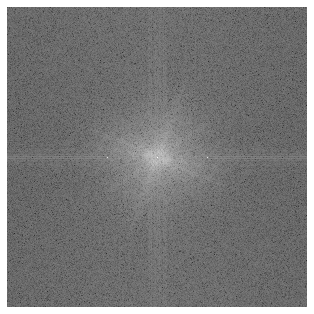

True

In [49]:
# read the input image
img = cv2.imread('images/cells.png', 0)

print("Input image:")
plot_img_orig(img)

# compute DFT and spectrum
img2_dft = np.fft.fft2(img) # compute DFT (no normalization to 1/MN)
img2_dft_shift = np.fft.fftshift(img2_dft) # shift FFT to the center
img2_spec_shift = np.absolute(img2_dft_shift)

# plot and save the log-normalized spectrum
print("Spectrum:")
img2_spec_shift_log = log_transformation(img2_spec_shift)
plot_img_orig(img2_spec_shift_log)
cv2.imwrite("output/spectrum3.png", img2_spec_shift_log)

Mask:


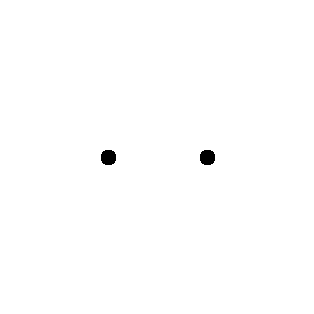

Masked spectrum:


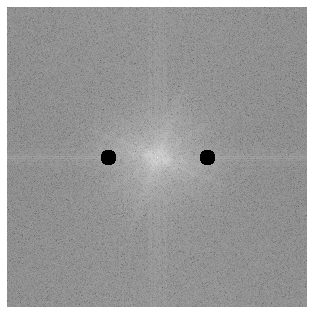

In [50]:
mask2 = cv2.imread('images/mask_exam.png', 0)
#mask2 = 255-mask2 # invert mask (can be used to check identified pattern)
print("Mask:")
plot_img_orig(mask2)
img2_dft_shift_res = np.multiply(mask2, img2_dft_shift)
print("Masked spectrum:")
plot_img_orig(log_transformation(np.absolute(img2_dft_shift_res)))

Result after IDFT (normalized):


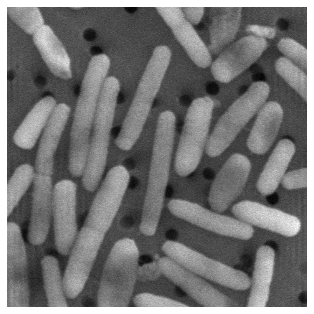

In [51]:
img2_dft_backshift = np.fft.ifftshift(img2_dft_shift_res) # shift centered FFT back to top left
img2_idft = np.fft.ifft2(img2_dft_backshift) # compute IDFT
img2_back = np.real(img2_idft) # take only real part, as all imaginary parts are parasitic
img2_back_n = cv2.normalize(img2_back, None, 0, 255, cv2.NORM_MINMAX)
print("Result after IDFT (normalized):")
plot_img_orig(img2_back_n)

<div style="font-size:1.4em;"><span style="color:RoyalBlue; font-weight:bold;">Task 6.4</span> (5 P)</div>

The following color image with $60 \times 300$ pixels has been created based on the grayscale image *stripes.png*. Use this grayscale image to reproduce the color image by programming and plot the result.

<p style="text-align:center;">
  <img src="images/stripes-color.png" width="300px" />
</p>

In [52]:
# read the input image
img = cv2.imread('images/stripes.png', 0)

# ...

<div style="font-size:1.4em;"><span style="color:RoyalBlue; font-weight:bold;">Task 7.2</span> (5 P)</div>

An image with $30 \times 30$ pixels has been compressed using LZW Coding. The code and corresponding dictionary are given (imported from the file *cmp.py* as shown below). Decode the image and plot the result.

In [53]:
# write your code in this field

# import LZW code and dictionary 
import cmp

# example: print code
print(cmp.code)

# example: access and print entry 100 of the dictionary
print(cmp.dict[100])

# ...

[  1   2   3   4   0   6   7   8   4  10  11  10   8  14   0  12  17   1
   9  18  20  18  19   7  23  22  12   6  23  17  29  28  16  30  11  32
   5  34  35  31  39  24  40  21  42  37  44  13  46  42  48   3  32  15
  55  56  57  58  59  59   2  20  58  62  25  24  54  66  64  67  34  63
  72  14  65  65  73  68  77  69  74  78  50  27  80  47  27  15  36  75
  53  66  52  41  47  94  49  76  48  87  50  52 101  38  90  56  90 105
  49 107  98 112 103  51  92  97  96 110 115  38 118 106 120  92 122  45
 111 117  57  23]
[255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 0]


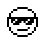

In [54]:
output = np.array([])
x = 0
while(x < cmp.code.size):
    codeword = cmp.code[x]
    output = np.append(output, cmp.dict[codeword])
    x+=1
plot_img_orig(output.reshape(30,30))